In [1]:
import networkx as nx
import sys
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

In [2]:
class Planner:
    def __init__(self, graph, execution_order, handle_lifetimes, handle_to_size, compute_costs, handle_types, bus_bandwidth_gbps, handle_usage_schedule):
        self.graph = graph; self.execution_order = execution_order; self.handle_lifetimes = handle_lifetimes; self.handle_to_size = handle_to_size; self.compute_costs = compute_costs; self.handle_types = handle_types; self.bus_bandwidth_gbps = bus_bandwidth_gbps; self.handle_usage_schedule = handle_usage_schedule; self.bus_bandwidth_bps = bus_bandwidth_gbps * 1024**3
    
    def _find_peak(self, strategy_plan):
        peak_gpu_memory, peak_op_id, peak_on_gpu_set_before_op = 0.0, None, set()
        on_gpu = set(); cp = strategy_plan.get('checkpoint', set()); ow = strategy_plan.get('offload_writable', set()); oro = strategy_plan.get('offload_read_only', set())
        for op_id in self.execution_order:
            node_data = self.graph.nodes[op_id]; on_gpu_before_op = on_gpu.copy()
            for handle, mode in zip(node_data['handles'], node_data['modes']):
                if 'W' not in mode and handle not in on_gpu and self.handle_lifetimes.get(handle, {}).get('producer') not in cp: on_gpu.add(handle)
            current_peak_candidate = sum(self.handle_to_size.get(h, 0) for h in on_gpu)
            for handle, mode in zip(node_data['handles'], node_data['modes']):
                if 'W' in mode and handle not in ow: current_peak_candidate += self.handle_to_size.get(handle, 0)
            if current_peak_candidate > peak_gpu_memory:
                peak_gpu_memory = current_peak_candidate; peak_op_id = op_id; peak_on_gpu_set_before_op = on_gpu_before_op.copy()
            for handle, mode in zip(node_data['handles'], node_data['modes']):
                if 'W' in mode and handle not in on_gpu and handle not in ow: on_gpu.add(handle)
            for handle in on_gpu.copy():
                if (self.handle_lifetimes.get(handle, {}).get('last_consumer') == op_id or self.handle_lifetimes.get(handle, {}).get('producer') in cp or (self.handle_types.get(handle) == 'read_only' and handle in oro)): on_gpu.remove(handle)
        return {"peak_memory_bytes": peak_gpu_memory, "peak_op_id": peak_op_id, "peak_on_gpu_set": peak_on_gpu_set_before_op}
    
    def create_checkpointing_plan(self, memory_limit_bytes, allow_checkpointing=True, allow_offloading=True):
        strategy_plan = {'checkpoint': set(), 'offload_writable': set(), 'offload_read_only': set()}
        mode_desc = [m for m, a in [("Чекпоинтинг", allow_checkpointing), ("Оффлоадинг", allow_offloading)] if a]
        
        print(f"\n- Запуск планировщика в режиме: {', '.join(mode_desc)}")
        
        for i in range(len(self.graph.nodes) * 3):
            sim_result = self._find_peak(strategy_plan)
            current_peak = sim_result['peak_memory_bytes']
            
            if current_peak <= memory_limit_bytes:
                print(f"  Успех! План найден.")
                return strategy_plan
            
            peak_op_id, live_handles_at_peak = sim_result['peak_op_id'], sim_result['peak_on_gpu_set']
            
            if not peak_op_id:
                print("  Не удалось определить пиковую операцию. Остановка.")
                break
            
            peak_op_index = self.execution_order.index(peak_op_id)
            possible_moves = []
            peak_op_inputs = {h for h, m in zip(self.graph.nodes[peak_op_id]['handles'], self.graph.nodes[peak_op_id]['modes']) if 'W' not in m}
            
            for handle in live_handles_at_peak - peak_op_inputs:
                size = self.handle_to_size.get(handle, 0)
                if size == 0:
                    continue
                future_uses = [idx for idx in self.handle_usage_schedule.get(handle, []) if idx > peak_op_index]
                reuse_distance = future_uses[0] - peak_op_index if future_uses else sys.maxsize
                
                if allow_checkpointing and self.handle_types.get(handle) == 'writable' and (producer := self.handle_lifetimes.get(handle, {}).get('producer')) and producer not in strategy_plan['checkpoint']:
                    possible_moves.append({'type': 'checkpoint', 'id': producer, 'cost': self.compute_costs.get(producer, 0), 'saving': size, 'distance': reuse_distance})
                if allow_offloading:
                    cost = (size / self.bus_bandwidth_bps) * 2
                    if self.handle_types.get(handle) == 'writable' and handle not in strategy_plan['offload_writable']:
                        possible_moves.append({'type': 'offload_writable', 'id': handle, 'cost': cost, 'saving': size, 'distance': reuse_distance})
                    if self.handle_types.get(handle) == 'read_only' and handle not in strategy_plan['offload_read_only']: 
                        possible_moves.append({'type': 'offload_read_only', 'id': handle, 'cost': cost, 'saving': size, 'distance': reuse_distance})
            if not possible_moves:
                print(f"❌ Не удалось найти план, укладывающийся в лимит.")
                break
            best_move = min(possible_moves, key=lambda x: x['cost'] / (x['saving'] * math.log(2 + x['distance'])))
            
            strategy_plan[best_move['type']].add(best_move['id'])

        else:
            
            print(f"❌ Не удалось найти план, укладывающийся в лимит.")
        
        return strategy_plan

In [3]:
def create_offloading_plan(graph, execution_order, handle_lifetimes, handle_to_size, memory_limit_bytes, handle_usage_schedule):
    print(f"\n- Запуск планировщика в режиме: Оффлоадинг")
    current_gpu_memory, on_gpu = 0.0, set()
    
    offload_plan = {op_id: set() for op_id in execution_order}
    op_to_index = {op_id: i for i, op_id in enumerate(execution_order)}

    for op_index, op_id in enumerate(execution_order):
        node_data = graph.nodes[op_id]
        
        for handle, mode in zip(node_data['handles'], node_data['modes']):
            if 'W' not in mode and handle not in on_gpu:
                current_gpu_memory += handle_to_size.get(handle, 0)
                on_gpu.add(handle)
        
        outputs_size = sum(handle_to_size.get(h, 0) for h, m in zip(node_data['handles'], node_data['modes']) if 'W' in m and h not in on_gpu)
        
        while current_gpu_memory + outputs_size > memory_limit_bytes:
            current_inputs = {h for h, m in zip(node_data['handles'], node_data['modes']) if 'W' not in m}
            candidates = on_gpu - current_inputs
            if not candidates: break

            candidate_distances = {h: (fu[0] - op_index if (fu := [i for i in handle_usage_schedule.get(h, []) if i > op_index]) else sys.maxsize) for h in candidates}
            if not candidate_distances: break
            victim = max(candidate_distances, key=candidate_distances.get)
            
            last_consumer_op = handle_lifetimes.get(victim, {}).get('last_consumer')
            
            if last_consumer_op and op_to_index.get(last_consumer_op, -1) < op_index:
                offload_plan[last_consumer_op].add(victim)
            else:
                if op_index > 0:
                    prev_op_id = execution_order[op_index - 1]
                    offload_plan[prev_op_id].add(victim)
            
            if victim in on_gpu:
                current_gpu_memory -= handle_to_size.get(victim, 0)
                on_gpu.remove(victim)
        
        for handle, mode in zip(node_data['handles'], node_data['modes']):
            if 'W' in mode and handle not in on_gpu:
                current_gpu_memory += handle_to_size.get(handle, 0)
                on_gpu.add(handle)
        
        for handle in on_gpu.copy():
            if handle_lifetimes.get(handle, {}).get('last_consumer') == op_id:
                current_gpu_memory -= handle_to_size.get(handle, 0)
                on_gpu.remove(handle)

    final_plan = {op: handles for op, handles in offload_plan.items() if handles}
    print(f"  Успех! План найден.")
    return final_plan

In [4]:
def simulate(graph, execution_order, handle_lifetimes, handle_to_size, compute_costs, handle_types, bus_bandwidth_gbps, memory_limit_bytes=float('inf'), strategy_mode='ideal', strategy_plan=None, offload_schedule=None):
    current_gpu_memory, peak_gpu_memory, current_time = 0.0, 0.0, 0.0
    on_gpu, stored_on_cpu, lru_access_times = set(), set(), {}
    bus_bandwidth_bps = bus_bandwidth_gbps * 1024**3
    timeline_events = []
    
    cp, ow, oro = set(), set(), set()
    if strategy_mode == 'planned' and strategy_plan:
        cp = strategy_plan.get('checkpoint', set()); ow = strategy_plan.get('offload_writable', set()); oro = strategy_plan.get('offload_read_only', set())
    
    for op_index, op_id in enumerate(execution_order):
        node_data = graph.nodes[op_id]
        
        for handle, mode in zip(node_data['handles'], node_data['modes']):
            if 'W' not in mode and handle not in on_gpu:
                size = handle_to_size.get(handle, 0)
                producer = handle_lifetimes.get(handle, {}).get('producer')
                duration = 0
                if producer in cp:
                    duration = compute_costs.get(producer, 0)
                    timeline_events.append({'type': 'recompute', 'start': current_time, 'end': current_time + duration, 'duration': duration})
                else:
                    duration = size / bus_bandwidth_bps
                    timeline_events.append({'type': 'transfer', 'start': current_time, 'end': current_time + duration, 'duration': duration})
                    if handle in stored_on_cpu: stored_on_cpu.remove(handle)
                current_time += duration
                current_gpu_memory += size
                on_gpu.add(handle)
            lru_access_times[handle] = op_index

        if memory_limit_bytes != float('inf'):
            outputs_size = sum(handle_to_size.get(h, 0) for h, m in zip(node_data['handles'], node_data['modes']) if 'W' in m and h not in on_gpu and h not in ow)
            while current_gpu_memory + outputs_size > memory_limit_bytes:
                current_inputs = {h for h, m in zip(node_data['handles'], node_data['modes']) if 'W' not in m}
                candidates = {h:t for h,t in lru_access_times.items() if h in on_gpu and h not in current_inputs}
                if not candidates: break
                victim = min(candidates, key=candidates.get)
                size = handle_to_size.get(victim, 0)
                duration = size / bus_bandwidth_bps
                timeline_events.append({'type': 'transfer', 'start': current_time, 'end': current_time + duration, 'duration': duration})
                current_time += duration
                current_gpu_memory -= size
                on_gpu.remove(victim); stored_on_cpu.add(victim); del lru_access_times[victim]
        
        duration = compute_costs.get(op_id, 0)
        timeline_events.append({'type': 'compute', 'start': current_time, 'end': current_time + duration, 'duration': duration})
        current_time += duration
        
        for i, handle in enumerate(node_data['handles']):
            if 'W' in node_data['modes'][i]:
                size = handle_to_size.get(handle, 0)
                if handle in ow:
                    duration = size / bus_bandwidth_bps
                    timeline_events.append({'type': 'transfer', 'start': current_time, 'end': current_time + duration, 'duration': duration})
                    current_time += duration
                    stored_on_cpu.add(handle)
                elif handle not in on_gpu:
                    current_gpu_memory += size
                    on_gpu.add(handle)
                    lru_access_times[handle] = op_index
        
        peak_gpu_memory = max(peak_gpu_memory, current_gpu_memory)
        
        for handle in on_gpu.copy():
            is_dead = handle_lifetimes.get(handle, {}).get('last_consumer') == op_id
            producer = handle_lifetimes.get(handle, {}).get('producer')
            is_from_checkpointed = producer in cp
            is_readonly_offloaded = handle in oro
            if is_dead or (strategy_mode == 'planned' and (is_from_checkpointed or is_readonly_offloaded)):
                current_gpu_memory -= handle_to_size.get(handle, 0)
                on_gpu.remove(handle)
                if handle in lru_access_times: del lru_access_times[handle]

        if strategy_mode == 'planned_offload' and offload_schedule and op_id in offload_schedule:
            for victim in offload_schedule[op_id]:
                if victim in on_gpu:
                    size = handle_to_size.get(victim, 0)
                    duration = size / bus_bandwidth_bps
                    timeline_events.append({'type': 'transfer', 'start': current_time, 'end': current_time + duration, 'duration': duration})
                    current_time += duration
                    current_gpu_memory -= size
                    on_gpu.remove(victim); stored_on_cpu.add(victim)
                    if victim in lru_access_times: del lru_access_times[victim]
    
    compute_time = sum(e['duration'] for e in timeline_events if e['type'] in ['compute', 'recompute'])
    transfer_time = sum(e['duration'] for e in timeline_events if e['type'] == 'transfer')
                
    return {
        "peak_memory_bytes": peak_gpu_memory, 
        "total_time_sec": current_time, 
        "timeline_events": timeline_events,
        "compute_time": compute_time,
        "transfer_time": transfer_time
    }

In [5]:
def plot_timeline_matplotlib(results):
    strategy_names = list(results.keys())
    y_pos = range(len(strategy_names))
    
    fig, ax = plt.subplots(figsize=(14, 8))

    compute_color = "#0CB03A"  # Спокойный бирюзово-зеленый
    transfer_color = "#be0a0a" # Мягкий оранжево-красный

    has_data = any(res.get('timeline_events') for res in results.values())

    if not has_data:
        ax.text(0.5, 0.5, 'Нет данных для отображения', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=16)
        ax.set_yticks([])
        ax.set_xticks([])
    else:
        for i, (name, res) in enumerate(results.items()):
            if 'timeline_events' not in res: continue
            for event in res['timeline_events']:
                color = compute_color if event['type'] in ['compute', 'recompute'] else transfer_color
                ax.barh(
                    y=i, 
                    width=event['duration'], 
                    left=event['start'], 
                    height=0.6, 
                    color=color,
                    align='center'
                )

        ax.set_yticks(y_pos)
        ax.set_yticklabels(strategy_names)
        #ax.set_xlim(0,3.7)
        ax.invert_yaxis()

        ax.set_xlabel('Время выполнения (секунды)')
        
        green_patch = mpatches.Patch(color=compute_color, label='Работа GPU')
        red_patch = mpatches.Patch(color=transfer_color, label='Простой GPU')
        ax.legend(handles=[green_patch, red_patch], bbox_to_anchor=(1.05, 1), loc='upper left')

        ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [6]:
scenario_set = {1 : 'mini_batch_size = 1, mini_batch_idx = 0',
                2 : 'mini_batch_size = 1, mini_batch_idxs = 0, 1, 2, 3',
                3 : 'mini_batch_size = 4, mini_batch_idx = 0'
                }

scenario = scenario_set[3]

file_name = 'examples/tasks_mbs4.rec'

minibatches_to_analyze = [i for i in range(1)]

In [7]:
records = []
try:
    with open(file_name, 'r', encoding='utf-8') as file:
        record = {}
        for line in file:
            line = line.strip()
            if line:
                key, value = line.split(': ', 1)
                record[key] = value
            else:
                if record: 
                    records.append(record)
                record = {}
        if record: 
            records.append(record)
except FileNotFoundError:
    print(f"Ошибка: Файл '{file_name}' не найден. Убедитесь, что он существует.")
    sys.exit()

all_minibatch_records = defaultdict(list)
task_fields = ['Name', 'JobId', 'EndTime', 'StartTime', 'Iteration', 'Modes', 'Sizes']
for rec in records:
  if 'Iteration' in rec.keys():
    try:
        iteration_vals = [int(elem) for elem in rec['Iteration'].split(' ')]
        if all(element in rec for element in task_fields) and rec['Name'][0] != '_' and rec['Name'] != 'task_build' and len(iteration_vals) == 2:
            idx_batch = iteration_vals[0]
            idx_minibatch = iteration_vals[1]
            if idx_batch == 0 and idx_minibatch in minibatches_to_analyze:
                all_minibatch_records[idx_minibatch].append(rec)
    except (ValueError, IndexError):
        continue

In [8]:
G = nx.DiGraph()
if scenario != scenario_set[2]:
    for idx_minibatch in minibatches_to_analyze:
        minibatch_records = all_minibatch_records[idx_minibatch]
        if not minibatch_records:
            print(f"Нет данных для мини-батча {idx_minibatch}, пропуск.")
            continue
        for record in minibatch_records:
            job_id = record["JobId"]
            G.add_node(job_id, name=record["Name"], handles=record.get("Handles", "").split(), sizes=[int(s) for s in record.get("Sizes", "").split() if s], modes=record.get("Modes", "").split())
        for record in minibatch_records:
            job_id = record["JobId"]
            depends_on = record.get("DependsOn")
            if depends_on:
                for dep in depends_on.split():
                    if dep in G.nodes():
                        G.add_edge(dep, job_id)
    try:
        linear_execution_order = list(nx.topological_sort(G))
        print(f"Граф для мини-батча {idx_minibatch} построен: {G.number_of_nodes()} узлов, {G.number_of_edges()} ребер.")
    except nx.NetworkXUnfeasible:
        print(f"Ошибка: в графе для мини-батча {idx_minibatch} обнаружен цикл. Пропуск.")

elif scenario == scenario_set[2]:
    for idx_minibatch in minibatches_to_analyze:
        minibatch_records = all_minibatch_records[idx_minibatch]
        if not minibatch_records:
            print(f"Нет данных для мини-батча {idx_minibatch}, пропуск.")
            continue
        for record in minibatch_records:
            job_id = record["JobId"]
            G.add_node(job_id, name=record["Name"], handles=record.get("Handles", "").split(), sizes=[int(s) for s in record.get("Sizes", "").split() if s], modes=record.get("Modes", "").split())
        for record in minibatch_records:
            job_id = record["JobId"]
            depends_on = record.get("DependsOn")
            if depends_on:
                for dep in depends_on.split():
                    if dep in G.nodes():
                        G.add_edge(dep, job_id)
    try:
        linear_execution_order = list(nx.topological_sort(G))
        print(f"Граф для мини-батчей {minibatches_to_analyze} построен: {G.number_of_nodes()} узлов, {G.number_of_edges()} ребер.")
    except nx.NetworkXUnfeasible:
        print(f"Ошибка: в графе для мини-батчей {minibatches_to_analyze} обнаружен цикл. Пропуск.")

Граф для мини-батча 0 построен: 5009 узлов, 6408 ребер.


In [9]:
handle_to_size = {}
for node_id in G.nodes():
    node_data = G.nodes[node_id]
    for i, handle in enumerate(node_data['handles']):
        if handle not in handle_to_size and i < len(node_data['sizes']):
            handle_to_size[handle] = node_data['sizes'][i]

compute_costs = {}
for record in records:
    if 'JobId' in record and 'StartTime' in record and 'EndTime' in record and record['JobId'] in G.nodes():
      try:
          duration = (float(record['EndTime']) - float(record['StartTime'])) / 1000.0
          compute_costs[record['JobId']] = max(duration, 1e-12)
      except (ValueError, TypeError): 
          compute_costs[record['JobId']] = 1e-12

handle_lifetimes = {}
all_handles = set(handle_to_size.keys())
for handle in all_handles:
    handle_lifetimes[handle] = {'producer': None, 'last_consumer': None, 'consumers': []}
for node_id in G.nodes():
    for handle in G.nodes[node_id]['handles']:
        if handle in handle_lifetimes: handle_lifetimes[handle]['consumers'].append(node_id)

for handle in handle_lifetimes:
    producers = [u for u in handle_lifetimes[handle]['consumers'] if 'W' in G.nodes[u]['modes'][G.nodes[u]['handles'].index(handle)]]
    if producers: handle_lifetimes[handle]['producer'] = min(producers, key=lambda p: linear_execution_order.index(p))
    consumers_indices = [linear_execution_order.index(c) for c in handle_lifetimes[handle]['consumers']]
    if consumers_indices: handle_lifetimes[handle]['last_consumer'] = linear_execution_order[max(consumers_indices)]

handle_types = {}
for handle in handle_to_size.keys():
    is_ever_written = False
    if handle in handle_lifetimes:
        for op_id in handle_lifetimes[handle]['consumers']:
            if 'W' in G.nodes[op_id]['modes'][G.nodes[op_id]['handles'].index(handle)]:
                is_ever_written = True; break
    handle_types[handle] = 'writable' if is_ever_written else 'read_only'
print(f"{len([t for t,v in handle_types.items() if v == 'read_only'])} Read-Only хэндлов,\n{len([t for t,v in handle_types.items() if v == 'writable'])} Writable хэндлов.")

handle_usage_schedule = {handle: [] for handle in all_handles}
for op_index, op_id in enumerate(linear_execution_order):
    for handle in G.nodes[op_id]['handles']:
        handle_usage_schedule[handle].append(op_index)

218 Read-Only хэндлов,
2376 Writable хэндлов.


In [10]:
print("\n--- Запуск и симуляция всех стратегий управления памятью ---")
BUS_BANDWIDTH_GBPS = 13
SIMULATE_ARGS = {"graph": G, "execution_order": linear_execution_order, "handle_lifetimes": handle_lifetimes, "handle_to_size": handle_to_size, "compute_costs": compute_costs, "handle_types": handle_types, "bus_bandwidth_gbps": BUS_BANDWIDTH_GBPS}
PLANNER_ARGS = {**SIMULATE_ARGS, "handle_usage_schedule": handle_usage_schedule}
PROFILER_ARGS = {"graph": G, "execution_order": linear_execution_order, "handle_lifetimes": handle_lifetimes, "handle_to_size": handle_to_size, "handle_usage_schedule": handle_usage_schedule}

ideal_sim = simulate(**SIMULATE_ARGS, strategy_mode='ideal')
GPU_MEMORY_LIMIT = 1349 * 1024 ** 2#ideal_sim['peak_memory_bytes'] * 0.382 if ideal_sim['peak_memory_bytes'] > 0 else 0
print(f"\n  Пик памяти в идеальном случае: {ideal_sim['peak_memory_bytes'] / 1024**2:.2f} MB.")
print(f"  Установлен целевой лимит GPU: {GPU_MEMORY_LIMIT / 1024**2:.2f} MB.")

lru_sim = simulate(**SIMULATE_ARGS, memory_limit_bytes=GPU_MEMORY_LIMIT, strategy_mode='lru')

static_offload_plan = create_offloading_plan(**PROFILER_ARGS, memory_limit_bytes=GPU_MEMORY_LIMIT)
planned_offload_sim = simulate(**SIMULATE_ARGS, memory_limit_bytes=GPU_MEMORY_LIMIT, strategy_mode='planned_offload', offload_schedule=static_offload_plan)

planner = Planner(**PLANNER_ARGS)
combined_plan = planner.create_checkpointing_plan(GPU_MEMORY_LIMIT, allow_checkpointing=True, allow_offloading=True)
combined_sim = simulate(**SIMULATE_ARGS, memory_limit_bytes=GPU_MEMORY_LIMIT, strategy_mode='planned', strategy_plan=combined_plan)


--- Запуск и симуляция всех стратегий управления памятью ---

  Пик памяти в идеальном случае: 3512.44 MB.
  Установлен целевой лимит GPU: 1349.00 MB.

- Запуск планировщика в режиме: Оффлоадинг
  Успех! План найден.

- Запуск планировщика в режиме: Чекпоинтинг, Оффлоадинг
  Успех! План найден.


In [11]:
print(f'\nПараметры симуляции:')
print(f'  Скорость передачи данных: {BUS_BANDWIDTH_GBPS} ГБ/с')
print(f'  Общий объем данных: {sum(handle_to_size.values()) / 1024**2:.2f} МБ')
print(f'  Размер памяти GPU: {GPU_MEMORY_LIMIT / 1024**2:.2f} МБ')

results = {
    "LRU (StarPU)": lru_sim, 
    "Оффлоадинг": planned_offload_sim,
    "Чекпоинтинг + Оффлоадинг": combined_sim
}

print("\n" + "="*48 + " ФИНАЛЬНЫЙ ОТЧЕТ " + "="*48)
print(f"{'Стратегия':<25} | {'Пик. память (МБ)':<18} | {'Общее время (с)':<18} | {'Вычисления (с)':<18} | {'Пересылки (с)':<18}")
print("-" * 115)
for name, res in results.items():
    print(f"{name:<25} | {res['peak_memory_bytes']/(1024**2):<18.2f} | {res['total_time_sec']:<18.4f} | {res.get('compute_time', 0):<18.4f} | {res.get('transfer_time', 0):<18.4f}")
print("=" * 115)


print("\n----- Ускорение относительно LRU (StarPU) -----")
base_time = results["LRU (StarPU)"]['total_time_sec']
for name, res in results.items():
    if name not in ["LRU (StarPU)"] and res['total_time_sec'] > 0:
        accel = ((base_time / res['total_time_sec']) - 1) * 100
        print(f"{name:<35}: {accel:>8.2f}%")


Параметры симуляции:
  Скорость передачи данных: 13 ГБ/с
  Общий объем данных: 14456.12 МБ
  Размер памяти GPU: 1349.00 МБ

================================================ ФИНАЛЬНЫЙ ОТЧЕТ ================================================
Стратегия                 | Пик. память (МБ)   | Общее время (с)    | Вычисления (с)     | Пересылки (с)     
-------------------------------------------------------------------------------------------------------------------
LRU (StarPU)              | 1348.90            | 1.5491             | 1.1082             | 0.4408            
Оффлоадинг                | 1348.79            | 1.4086             | 1.1082             | 0.3004            
Чекпоинтинг + Оффлоадинг  | 1347.04            | 1.1678             | 1.1166             | 0.0512            

----- Ускорение относительно LRU (StarPU) -----
Оффлоадинг                         :     9.97%
Чекпоинтинг + Оффлоадинг           :    32.65%


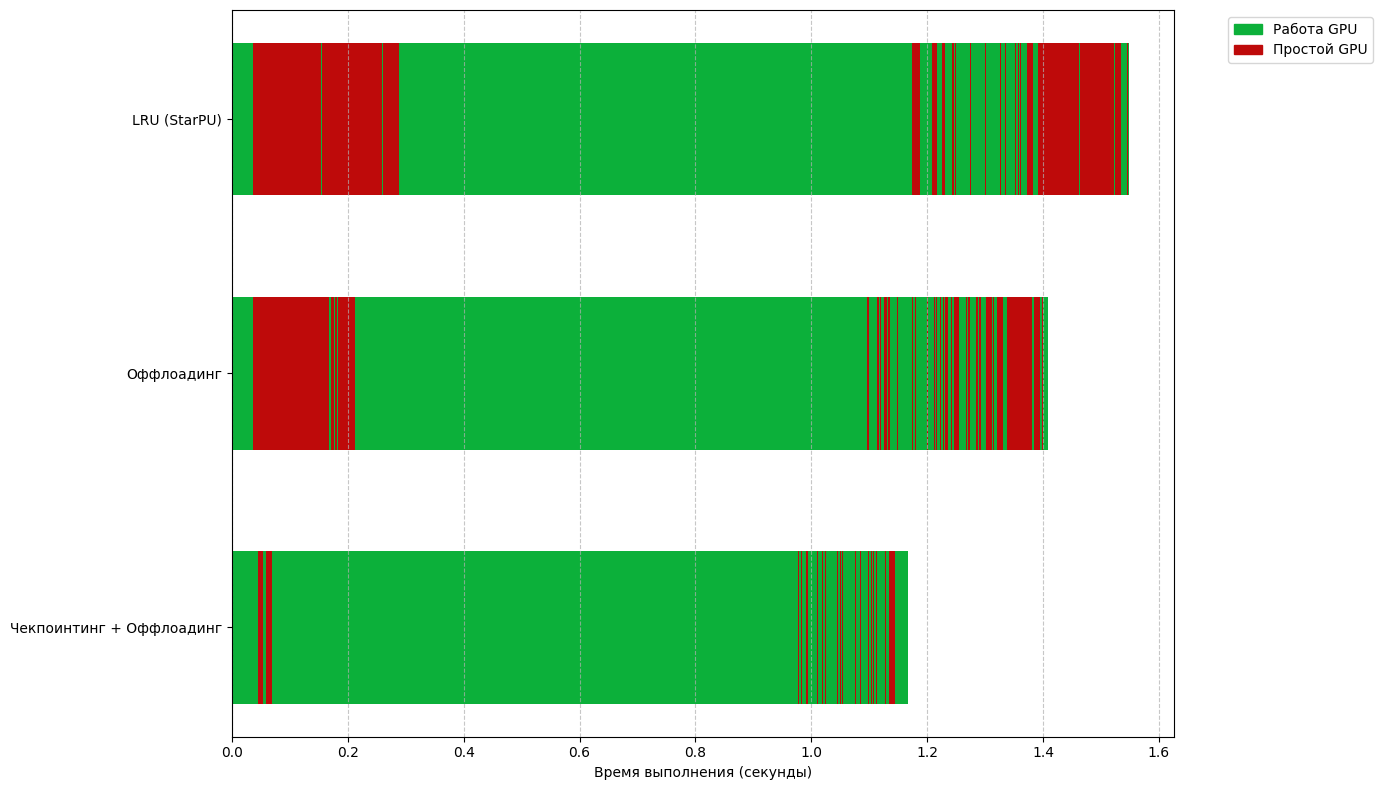

In [12]:
plot_timeline_matplotlib(results)